In [1]:
# =========================
# CÉLULA 1 - IMPORTAÇÕES
# =========================

# Biblioteca para cálculos matemáticos
import numpy as np

# Biblioteca para gráficos
import matplotlib.pyplot as plt

# Biblioteca para interface interativa no Colab
import ipywidgets as widgets

# Funções para exibir e limpar saídas
from IPython.display import display, clear_output

# Biblioteca para treinar a Rede Neural
from sklearn.neural_network import MLPRegressor

# Divide dados entre treino e teste
from sklearn.model_selection import train_test_split

# Métricas de avaliação da RNA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# biblioteca do Colab para acessar Secrets
from google.colab import userdata

# cliente oficial do Gemini
from google import genai

# biblioteca para acessar variáveis do sistema
import os

In [35]:

# instala a biblioteca oficial do Gemini
!pip install -q -U google-genai

In [3]:
# Recupera a chave da API Gemini salva no painel Secrets do Google Colab
api_key = userdata.get("FESA_API_KEY")

# Valida se a chave foi encontrada antes de continuar
if api_key is None:
    raise ValueError("API Key não encontrada. Verifique se a chave FESA_API_KEY foi cadastrada no Secrets do Colab.")

# Define a chave no ambiente para uso pela biblioteca do Gemini
os.environ["GEMINI_API_KEY"] = api_key

print("API Key configurada com sucesso.")

API Key configurada com sucesso.


In [4]:
# Inicializa o cliente Gemini com tratamento de erro
try:
    client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
    print("Conexão com Gemini pronta.")
except Exception as erro:
    raise RuntimeError(f"Erro ao inicializar o cliente Gemini: {erro}")

Conexão com Gemini pronta.


In [5]:
# =========================
# CÉLULA 2 - CONCEITO DO SISTEMA
# =========================

print("""
SISTEMA INTELIGENTE DE CONTROLE DE AGVs EM ESTOQUE

Neste projeto, vários robôs AGVs circulam em uma mesma linha/corredor.

A variável principal será a URGÊNCIA DE ENTREGA.

A urgência será usada para definir:

1. Prioridade de passagem
2. Velocidade recomendada
3. Distância segura entre robôs
4. Ação de controle para evitar colisão
5. Compensação de velocidade após ceder passagem

Regra principal:

- AGV com maior urgência mantém prioridade e velocidade normal.
- AGV com menor urgência reduz temporariamente a velocidade.
- Após a passagem do AGV prioritário, o AGV que reduziu compensa velocidade.
""")


SISTEMA INTELIGENTE DE CONTROLE DE AGVs EM ESTOQUE

Neste projeto, vários robôs AGVs circulam em uma mesma linha/corredor.

A variável principal será a URGÊNCIA DE ENTREGA.

A urgência será usada para definir:

1. Prioridade de passagem
2. Velocidade recomendada
3. Distância segura entre robôs
4. Ação de controle para evitar colisão
5. Compensação de velocidade após ceder passagem

Regra principal:

- AGV com maior urgência mantém prioridade e velocidade normal.
- AGV com menor urgência reduz temporariamente a velocidade.
- Após a passagem do AGV prioritário, o AGV que reduziu compensa velocidade.



In [6]:
# =========================
# CÉLULA 3 - CÁLCULO DA URGÊNCIA DO AGV
# =========================

def calcular_urgencia(
    tempo_restante,
    distancia_destino,
    prioridade_entrega
):
    """
    Calcula a urgência do AGV.

    Parâmetros:
    - tempo_restante: tempo disponível para entregar, em minutos
    - distancia_destino: distância até o destino, em metros
    - prioridade_entrega: prioridade da entrega, de 0 a 100

    Quanto menor o tempo restante,
    maior a distância e maior a prioridade,
    maior será a urgência.
    """

    # Evita divisão por zero
    tempo_restante = max(tempo_restante, 1)

    # Pressão de tempo
    pressao_tempo = 100 / tempo_restante

    # Pressão por distância
    pressao_distancia = distancia_destino / 10

    # Peso da prioridade da entrega
    peso_prioridade = prioridade_entrega

    # Cálculo ponderado da urgência
    urgencia = (
        pressao_tempo * 0.4 +
        pressao_distancia * 0.2 +
        peso_prioridade * 0.4
    )

    # Limita a urgência entre 0 e 100
    urgencia = max(0, min(urgencia, 100))

    return urgencia

In [7]:
urgencia = calcular_urgencia(
    tempo_restante=5,
    distancia_destino=80,
    prioridade_entrega=90
)

print(f"Urgência calculada: {urgencia:.2f}%")

Urgência calculada: 45.60%


In [8]:
# =========================
# CÉLULA 4 - PARÂMETROS DEFINIDOS PELA URGÊNCIA
# =========================

def definir_parametros_por_urgencia(urgencia):
    """
    Define os parâmetros operacionais do AGV com base na urgência.

    Quanto maior a urgência:
    - maior a prioridade de passagem
    - maior a velocidade recomendada
    - menor a tolerância para atrasos
    - maior a necessidade de manter fluxo livre
    """

    if urgencia >= 70:
        prioridade_passagem = "ALTA"
        estado_semaforo = "VERDE"
        velocidade_recomendada = 80
        distancia_segura = 20
        acao = "Manter velocidade e receber prioridade de passagem"

    elif urgencia >= 35:
        prioridade_passagem = "MÉDIA"
        estado_semaforo = "AMARELO"
        velocidade_recomendada = 55
        distancia_segura = 30
        acao = "Seguir com atenção e ajustar velocidade se necessário"

    else:
        prioridade_passagem = "BAIXA"
        estado_semaforo = "VERMELHO"
        velocidade_recomendada = 35
        distancia_segura = 40
        acao = "Reduzir velocidade e ceder passagem para AGVs mais urgentes"

    return {
        "prioridade_passagem": prioridade_passagem,
        "estado_semaforo": estado_semaforo,
        "velocidade_recomendada": velocidade_recomendada,
        "distancia_segura": distancia_segura,
        "acao": acao
    }

In [9]:
urgencia = calcular_urgencia(
    tempo_restante=5,
    distancia_destino=80,
    prioridade_entrega=90
)

parametros = definir_parametros_por_urgencia(urgencia)

print(f"Urgência: {urgencia:.2f}%")
print(f"Prioridade de passagem: {parametros['prioridade_passagem']}")
print(f"Semáforo: {parametros['estado_semaforo']}")
print(f"Velocidade recomendada: {parametros['velocidade_recomendada']}")
print(f"Distância segura: {parametros['distancia_segura']}")
print(f"Ação: {parametros['acao']}")

Urgência: 45.60%
Prioridade de passagem: MÉDIA
Semáforo: AMARELO
Velocidade recomendada: 55
Distância segura: 30
Ação: Seguir com atenção e ajustar velocidade se necessário


In [10]:
# =========================
# NOVA CÉLULA 5 - GERAR AGVs EM MÚLTIPLOS CRUZAMENTOS
# =========================

agvs = []

quantidade_agvs = 100

corredores = ["A", "B", "C", "D", "E"]

cruzamentos = [
    "Cruzamento_01",
    "Cruzamento_02",
    "Cruzamento_03",
    "Cruzamento_04",
    "Cruzamento_05"
]

for i in range(quantidade_agvs):

    corredor = np.random.choice(corredores)

    cruzamento_destino = np.random.choice(cruzamentos)

    distancia_cruzamento = np.random.randint(10, 120)

    velocidade_atual = np.random.randint(20, 80)

    tempo_chegada_cruzamento = distancia_cruzamento / velocidade_atual

    agv = {
        "id": f"AGV_{i+1:03}",
        "corredor": corredor,
        "cruzamento_destino": cruzamento_destino,
        "tempo_restante": np.random.randint(3, 30),
        "distancia_destino": np.random.randint(20, 150),
        "prioridade_entrega": np.random.randint(0, 101),
        "distancia_cruzamento": distancia_cruzamento,
        "velocidade_atual": velocidade_atual,
        "tempo_chegada_cruzamento": tempo_chegada_cruzamento
    }

    agvs.append(agv)

print("=" * 80)
print(f"{quantidade_agvs} AGVs gerados em múltiplos corredores e cruzamentos.")
print("=" * 80)

for agv in agvs[:10]:
    print(
        f"{agv['id']} | "
        f"Corredor: {agv['corredor']} | "
        f"Cruzamento: {agv['cruzamento_destino']} | "
        f"Tempo chegada: {agv['tempo_chegada_cruzamento']:.2f} | "
        f"Velocidade: {agv['velocidade_atual']} | "
        f"Prioridade: {agv['prioridade_entrega']}"
    )

print("\nExibindo apenas os 10 primeiros AGVs.")

100 AGVs gerados em múltiplos corredores e cruzamentos.
AGV_001 | Corredor: E | Cruzamento: Cruzamento_01 | Tempo chegada: 1.76 | Velocidade: 21 | Prioridade: 87
AGV_002 | Corredor: E | Cruzamento: Cruzamento_04 | Tempo chegada: 0.32 | Velocidade: 56 | Prioridade: 66
AGV_003 | Corredor: D | Cruzamento: Cruzamento_01 | Tempo chegada: 1.51 | Velocidade: 35 | Prioridade: 1
AGV_004 | Corredor: A | Cruzamento: Cruzamento_03 | Tempo chegada: 0.80 | Velocidade: 76 | Prioridade: 37
AGV_005 | Corredor: C | Cruzamento: Cruzamento_01 | Tempo chegada: 1.36 | Velocidade: 33 | Prioridade: 37
AGV_006 | Corredor: A | Cruzamento: Cruzamento_05 | Tempo chegada: 0.28 | Velocidade: 74 | Prioridade: 52
AGV_007 | Corredor: C | Cruzamento: Cruzamento_05 | Tempo chegada: 2.14 | Velocidade: 43 | Prioridade: 75
AGV_008 | Corredor: E | Cruzamento: Cruzamento_04 | Tempo chegada: 0.96 | Velocidade: 46 | Prioridade: 79
AGV_009 | Corredor: B | Cruzamento: Cruzamento_02 | Tempo chegada: 1.61 | Velocidade: 51 | Priori

In [11]:
# =========================
# CÉLULA 6 - PROCESSAMENTO DOS AGVs EM MÚLTIPLOS CRUZAMENTOS
# =========================

# Processa todos os AGVs
for agv in agvs:

    # Calcula urgência com base em:
    # tempo restante, distância até destino e prioridade da entrega
    urgencia = calcular_urgencia(
        agv["tempo_restante"],
        agv["distancia_destino"],
        agv["prioridade_entrega"]
    )

    # Define parâmetros operacionais pela urgência
    parametros = definir_parametros_por_urgencia(
        urgencia
    )

    # Salva resultados no próprio AGV
    agv["urgencia"] = urgencia
    agv["prioridade_passagem"] = parametros["prioridade_passagem"]
    agv["estado_semaforo"] = parametros["estado_semaforo"]
    agv["velocidade_recomendada"] = parametros["velocidade_recomendada"]
    agv["distancia_segura"] = parametros["distancia_segura"]
    agv["acao"] = parametros["acao"]

# Ordena por urgência
agvs_ordenados = sorted(
    agvs,
    key=lambda x: x["urgencia"],
    reverse=True
)

print("=" * 130)
print("PROCESSAMENTO DOS AGVs EM MÚLTIPLOS CRUZAMENTOS")
print("=" * 130)

for agv in agvs_ordenados[:20]:

    print("-" * 130)
    print(f"ID: {agv['id']}")
    print(f"Corredor: {agv['corredor']}")
    print(f"Cruzamento de destino: {agv['cruzamento_destino']}")
    print(f"Tempo até o cruzamento: {agv['tempo_chegada_cruzamento']:.2f}")
    print(f"Distância até cruzamento: {agv['distancia_cruzamento']} m")
    print(f"Velocidade atual: {agv['velocidade_atual']} km/h")
    print(f"Urgência: {agv['urgencia']:.2f}%")
    print(f"Semáforo: {agv['estado_semaforo']}")
    print(f"Velocidade recomendada: {agv['velocidade_recomendada']} km/h")
    print(f"Distância segura: {agv['distancia_segura']} m")
    print(f"Prioridade de passagem: {agv['prioridade_passagem']}")
    print(f"Ação: {agv['acao']}")

print("\nExibindo apenas os 20 AGVs mais urgentes.")

PROCESSAMENTO DOS AGVs EM MÚLTIPLOS CRUZAMENTOS
----------------------------------------------------------------------------------------------------------------------------------
ID: AGV_011
Corredor: E
Cruzamento de destino: Cruzamento_02
Tempo até o cruzamento: 2.02
Distância até cruzamento: 89 m
Velocidade atual: 44 km/h
Urgência: 48.86%
Semáforo: AMARELO
Velocidade recomendada: 55 km/h
Distância segura: 30 m
Prioridade de passagem: MÉDIA
Ação: Seguir com atenção e ajustar velocidade se necessário
----------------------------------------------------------------------------------------------------------------------------------
ID: AGV_001
Corredor: E
Cruzamento de destino: Cruzamento_01
Tempo até o cruzamento: 1.76
Distância até cruzamento: 37 m
Velocidade atual: 21 km/h
Urgência: 48.63%
Semáforo: AMARELO
Velocidade recomendada: 55 km/h
Distância segura: 30 m
Prioridade de passagem: MÉDIA
Ação: Seguir com atenção e ajustar velocidade se necessário
------------------------------------

In [12]:
# =========================
# CÉLULA 7 - CONTROLE DE COLISÃO EM MÚLTIPLOS CRUZAMENTOS
# =========================

# Janela de tempo crítica:
# se dois AGVs chegarem ao mesmo cruzamento com diferença menor ou igual a esse valor,
# existe risco de colisão.
JANELA_TEMPO_CRITICA = 0.25

# Lista para armazenar conflitos detectados
conflitos_detectados = []

print("=" * 120)
print("CONTROLE INTELIGENTE DE COLISÃO EM MÚLTIPLOS CRUZAMENTOS")
print("=" * 120)

# Agrupa AGVs por cruzamento
for cruzamento in cruzamentos:

    agvs_no_cruzamento = [
        agv for agv in agvs_ordenados
        if agv["cruzamento_destino"] == cruzamento
    ]

    # Ordena por tempo estimado de chegada ao cruzamento
    agvs_no_cruzamento = sorted(
        agvs_no_cruzamento,
        key=lambda x: x["tempo_chegada_cruzamento"]
    )

    print("\n" + "=" * 120)
    print(f"ANÁLISE DO {cruzamento}")
    print("=" * 120)

    if len(agvs_no_cruzamento) < 2:
        print("Apenas um AGV neste cruzamento. Sem risco de colisão.")
        continue

    # Compara AGVs que chegam em tempos próximos
    for i in range(len(agvs_no_cruzamento) - 1):

        agv_atual = agvs_no_cruzamento[i]
        agv_proximo = agvs_no_cruzamento[i + 1]

        diferenca_tempo = abs(
            agv_proximo["tempo_chegada_cruzamento"] -
            agv_atual["tempo_chegada_cruzamento"]
        )

        print("-" * 120)
        print(f"{agv_atual['id']} ↔ {agv_proximo['id']}")
        print(f"Tempo {agv_atual['id']}: {agv_atual['tempo_chegada_cruzamento']:.2f}")
        print(f"Tempo {agv_proximo['id']}: {agv_proximo['tempo_chegada_cruzamento']:.2f}")
        print(f"Diferença de tempo: {diferenca_tempo:.2f}")

        if diferenca_tempo <= JANELA_TEMPO_CRITICA:

            print("RISCO DE COLISÃO DETECTADO NO CRUZAMENTO")

            # AGV com maior urgência mantém prioridade
            if agv_atual["urgencia"] >= agv_proximo["urgencia"]:
                prioritario = agv_atual
                secundario = agv_proximo
            else:
                prioritario = agv_proximo
                secundario = agv_atual

            print(f"AGV prioritário: {prioritario['id']} | Urgência: {prioritario['urgencia']:.2f}%")
            print(f"AGV secundário: {secundario['id']} | Urgência: {secundario['urgencia']:.2f}%")

            # Redução de velocidade do AGV secundário
            velocidade_original = secundario["velocidade_recomendada"]

            diferenca_urgencia = abs(
                prioritario["urgencia"] - secundario["urgencia"]
            )

            reducao = min(
                35,
                max(10, diferenca_urgencia * 0.5)
            )

            nova_velocidade = max(
                velocidade_original - reducao,
                20
            )

            secundario["velocidade_temporaria"] = nova_velocidade
            secundario["cedeu_passagem"] = True
            secundario["cruzamento_conflito"] = cruzamento

            prioritario["cedeu_passagem"] = False
            prioritario["cruzamento_prioridade"] = cruzamento

            # Recalcula o tempo de chegada do secundário após reduzir velocidade
            secundario["tempo_chegada_ajustado"] = (
                secundario["distancia_cruzamento"] / nova_velocidade
            )

            conflito = {
                "cruzamento": cruzamento,
                "agv_prioritario": prioritario["id"],
                "agv_secundario": secundario["id"],
                "urgencia_prioritario": prioritario["urgencia"],
                "urgencia_secundario": secundario["urgencia"],
                "diferenca_tempo": diferenca_tempo,
                "velocidade_original_secundario": velocidade_original,
                "velocidade_temporaria_secundario": nova_velocidade,
                "tempo_original_secundario": secundario["tempo_chegada_cruzamento"],
                "tempo_ajustado_secundario": secundario["tempo_chegada_ajustado"]
            }

            conflitos_detectados.append(conflito)

            print(
                f"{secundario['id']} reduz velocidade de "
                f"{velocidade_original:.1f} para {nova_velocidade:.1f}"
            )

            print(
                f"Novo tempo estimado de chegada de {secundario['id']}: "
                f"{secundario['tempo_chegada_ajustado']:.2f}"
            )

            print(
                f"{prioritario['id']} mantém velocidade para cumprir a entrega."
            )

        else:
            print("Sem risco de colisão neste par.")

print("\n" + "=" * 120)
print(f"TOTAL DE CONFLITOS DETECTADOS: {len(conflitos_detectados)}")
print("=" * 120)

CONTROLE INTELIGENTE DE COLISÃO EM MÚLTIPLOS CRUZAMENTOS

ANÁLISE DO Cruzamento_01
------------------------------------------------------------------------------------------------------------------------
AGV_013 ↔ AGV_039
Tempo AGV_013: 0.31
Tempo AGV_039: 0.47
Diferença de tempo: 0.16
RISCO DE COLISÃO DETECTADO NO CRUZAMENTO
AGV prioritário: AGV_039 | Urgência: 30.76%
AGV secundário: AGV_013 | Urgência: 23.30%
AGV_013 reduz velocidade de 35.0 para 25.0
Novo tempo estimado de chegada de AGV_013: 0.72
AGV_039 mantém velocidade para cumprir a entrega.
------------------------------------------------------------------------------------------------------------------------
AGV_039 ↔ AGV_091
Tempo AGV_039: 0.47
Tempo AGV_091: 0.53
Diferença de tempo: 0.06
RISCO DE COLISÃO DETECTADO NO CRUZAMENTO
AGV prioritário: AGV_091 | Urgência: 37.26%
AGV secundário: AGV_039 | Urgência: 30.76%
AGV_039 reduz velocidade de 35.0 para 25.0
Novo tempo estimado de chegada de AGV_039: 0.88
AGV_091 mantém veloci

In [13]:
# =========================
# CÉLULA 8 - COMPENSAÇÃO DE VELOCIDADE EM MÚLTIPLOS CRUZAMENTOS
# =========================

print("=" * 120)
print("COMPENSAÇÃO DE VELOCIDADE APÓS CEDER PASSAGEM")
print("=" * 120)

for agv in agvs_ordenados:

    velocidade_base = agv["velocidade_recomendada"]

    if agv.get("cedeu_passagem") == True:

        velocidade_temporaria = agv["velocidade_temporaria"]

        velocidade_compensada = min(
            velocidade_base + 15,
            90
        )

        agv["velocidade_compensada"] = velocidade_compensada

        agv["tempo_entrega_base"] = (
            agv["distancia_destino"] / max(velocidade_base, 1)
        )

        agv["tempo_entrega_compensado"] = (
            agv["distancia_destino"] / max(velocidade_compensada, 1)
        )

        print("-" * 120)
        print(f"AGV: {agv['id']}")
        print(f"Cruzamento de conflito: {agv.get('cruzamento_conflito', 'Não informado')}")
        print(f"Urgência: {agv['urgencia']:.2f}%")
        print(f"Velocidade base: {velocidade_base:.1f} km/h")
        print(f"Velocidade temporária: {velocidade_temporaria:.1f} km/h")
        print(f"Velocidade compensada: {velocidade_compensada:.1f} km/h")
        print(f"Tempo base estimado: {agv['tempo_entrega_base']:.2f}")
        print(f"Tempo após compensação: {agv['tempo_entrega_compensado']:.2f}")
        print("Ação: cedeu passagem, reduziu velocidade temporariamente e compensou após o cruzamento.")

    else:

        agv["velocidade_compensada"] = velocidade_base

print("\nProcessamento de compensação concluído.")

COMPENSAÇÃO DE VELOCIDADE APÓS CEDER PASSAGEM
------------------------------------------------------------------------------------------------------------------------
AGV: AGV_027
Cruzamento de conflito: Cruzamento_02
Urgência: 39.68%
Velocidade base: 55.0 km/h
Velocidade temporária: 45.0 km/h
Velocidade compensada: 70.0 km/h
Tempo base estimado: 0.55
Tempo após compensação: 0.43
Ação: cedeu passagem, reduziu velocidade temporariamente e compensou após o cruzamento.
------------------------------------------------------------------------------------------------------------------------
AGV: AGV_049
Cruzamento de conflito: Cruzamento_01
Urgência: 33.56%
Velocidade base: 35.0 km/h
Velocidade temporária: 25.0 km/h
Velocidade compensada: 50.0 km/h
Tempo base estimado: 2.49
Tempo após compensação: 1.74
Ação: cedeu passagem, reduziu velocidade temporariamente e compensou após o cruzamento.
--------------------------------------------------------------------------------------------------------

In [14]:
# =========================
# CÉLULA 9 - DATASET PARA TREINAMENTO DA RNA
# =========================

# A RNA será treinada para aprender a urgência do AGV.
# A urgência é usada depois para decidir:
# - prioridade no cruzamento
# - velocidade recomendada
# - quem reduz velocidade
# - quem mantém passagem

X = []
y = []

quantidade_amostras = 5000

for _ in range(quantidade_amostras):

    tempo_restante = np.random.randint(1, 30)
    distancia_destino = np.random.randint(10, 150)
    prioridade_entrega = np.random.randint(0, 101)

    urgencia = calcular_urgencia(
        tempo_restante,
        distancia_destino,
        prioridade_entrega
    )

    X.append([
        tempo_restante,
        distancia_destino,
        prioridade_entrega
    ])

    y.append(urgencia)

X = np.array(X)
y = np.array(y)

print("=" * 60)
print("DATASET GERADO COM SUCESSO")
print("=" * 60)

print(f"Total de amostras: {len(X)}")
print(f"Formato das entradas X: {X.shape}")
print(f"Formato das saídas y: {y.shape}")

DATASET GERADO COM SUCESSO
Total de amostras: 5000
Formato das entradas X: (5000, 3)
Formato das saídas y: (5000,)


In [15]:
# =========================
# CÉLULA 10 - TREINAMENTO DA RNA
# =========================

import time

print("=" * 60)
print("INICIANDO TREINAMENTO DA RNA")
print("=" * 60)

# Divide os dados entre treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Cria a Rede Neural Artificial
modelo_rna = MLPRegressor(

    # Camadas ocultas
    hidden_layer_sizes=(64, 32),

    # Função de ativação
    activation='relu',

    # Algoritmo de otimização
    solver='adam',

    # Número máximo de épocas
    max_iter=1000,

    # Reprodutibilidade
    random_state=42
)

# Marca início do treinamento
inicio = time.time()

# Treina a RNA
modelo_rna.fit(
    X_treino,
    y_treino
)

# Marca fim
fim = time.time()

tempo_treinamento = fim - inicio

print("\n" + "=" * 60)
print("REDE NEURAL TREINADA COM SUCESSO")
print("=" * 60)

print(f"Amostras de treino: {len(X_treino)}")
print(f"Amostras de teste: {len(X_teste)}")

print()

print(f"Tempo de treinamento: {tempo_treinamento:.2f} segundos")

print(f"Perda final da RNA: {modelo_rna.loss_:.4f}")

INICIANDO TREINAMENTO DA RNA

REDE NEURAL TREINADA COM SUCESSO
Amostras de treino: 4000
Amostras de teste: 1000

Tempo de treinamento: 10.70 segundos
Perda final da RNA: 0.0534


AVALIAÇÃO DA REDE NEURAL
MAE: 0.24
RMSE: 0.35
R²: 0.9994
Acurácia aproximada: 99.76%


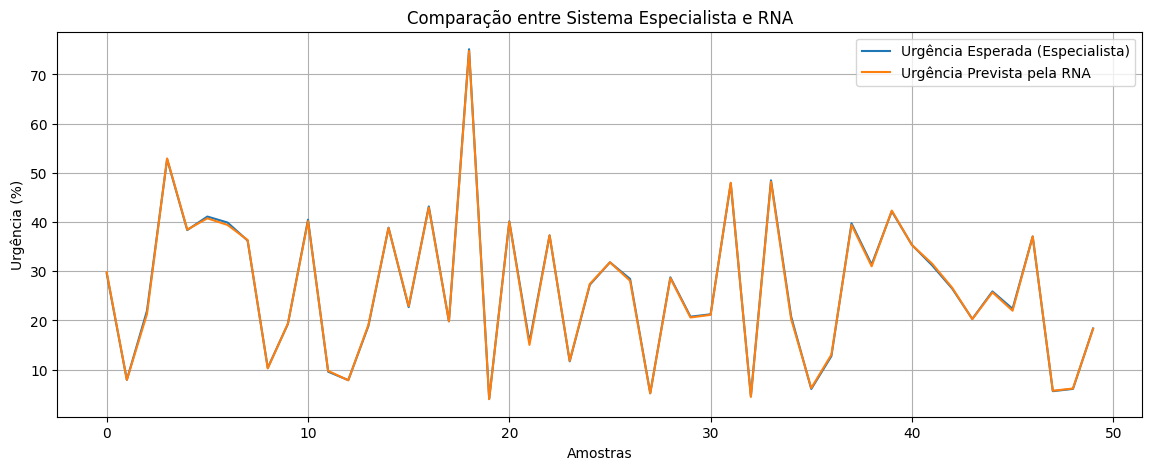

In [16]:
# =========================
# CÉLULA 11 - AVALIAÇÃO DA RNA
# =========================

# Faz previsões usando os dados de teste
y_pred = modelo_rna.predict(X_teste)

# =========================
# MÉTRICAS
# =========================

mae = mean_absolute_error(
    y_teste,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_teste,
        y_pred
    )
)

r2 = r2_score(
    y_teste,
    y_pred
)

# Acurácia aproximada
acuracia_aproximada = max(
    0,
    100 - mae
)

# =========================
# RESULTADOS
# =========================

print("=" * 60)
print("AVALIAÇÃO DA REDE NEURAL")
print("=" * 60)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"Acurácia aproximada: {acuracia_aproximada:.2f}%")

# =========================
# GRÁFICO
# =========================

# Seleciona apenas algumas amostras
amostras = 50

plt.figure(figsize=(14, 5))

plt.plot(
    y_teste[:amostras],
    label="Urgência Esperada (Especialista)"
)

plt.plot(
    y_pred[:amostras],
    label="Urgência Prevista pela RNA"
)

plt.title(
    "Comparação entre Sistema Especialista e RNA"
)

plt.ylabel("Urgência (%)")

plt.xlabel("Amostras")

plt.grid(True)

plt.legend()

plt.show()

In [17]:
# =========================
# CÉLULA 12 - RNA ANALISANDO OS AGVs EM MÚLTIPLOS CRUZAMENTOS
# =========================

print("=" * 120)
print("ANÁLISE DOS AGVs UTILIZANDO A RNA")
print("=" * 120)

for agv in agvs:

    # Entradas da RNA:
    # tempo restante, distância até destino e prioridade da entrega
    entrada_rna = [[
        agv["tempo_restante"],
        agv["distancia_destino"],
        agv["prioridade_entrega"]
    ]]

    # Previsão da urgência pela RNA
    urgencia_rna = modelo_rna.predict(
        entrada_rna
    )[0]

    # Limita o valor entre 0 e 100
    urgencia_rna = max(
        0,
        min(urgencia_rna, 100)
    )

    # Define parâmetros operacionais com base na urgência
    parametros = definir_parametros_por_urgencia(
        urgencia_rna
    )

    # Salva resultados no AGV
    agv["urgencia_rna"] = urgencia_rna
    agv["estado_semaforo_rna"] = parametros["estado_semaforo"]
    agv["velocidade_rna"] = parametros["velocidade_recomendada"]
    agv["distancia_segura_rna"] = parametros["distancia_segura"]
    agv["acao_rna"] = parametros["acao"]

# Ordena por urgência prevista pela RNA
agvs_rna = sorted(
    agvs,
    key=lambda x: x["urgencia_rna"],
    reverse=True
)

# Exibe apenas os 20 AGVs mais urgentes para não poluir a tela
for agv in agvs_rna[:20]:

    print("-" * 120)
    print(f"ID: {agv['id']}")
    print(f"Corredor: {agv['corredor']}")
    print(f"Cruzamento: {agv['cruzamento_destino']}")
    print(f"Tempo até cruzamento: {agv['tempo_chegada_cruzamento']:.2f}")
    print(f"Distância até cruzamento: {agv['distancia_cruzamento']} m")
    print(f"Velocidade atual: {agv['velocidade_atual']} km/h")
    print(f"Urgência RNA: {agv['urgencia_rna']:.2f}%")
    print(f"Semáforo: {agv['estado_semaforo_rna']}")
    print(f"Velocidade recomendada: {agv['velocidade_rna']} km/h")
    print(f"Distância segura: {agv['distancia_segura_rna']} m")
    print(f"Ação: {agv['acao_rna']}")

print("\nExibindo apenas os 20 AGVs mais urgentes.")

ANÁLISE DOS AGVs UTILIZANDO A RNA
------------------------------------------------------------------------------------------------------------------------
ID: AGV_011
Corredor: E
Cruzamento: Cruzamento_02
Tempo até cruzamento: 2.02
Distância até cruzamento: 89 m
Velocidade atual: 44 km/h
Urgência RNA: 48.85%
Semáforo: AMARELO
Velocidade recomendada: 55 km/h
Distância segura: 30 m
Ação: Seguir com atenção e ajustar velocidade se necessário
------------------------------------------------------------------------------------------------------------------------
ID: AGV_001
Corredor: E
Cruzamento: Cruzamento_01
Tempo até cruzamento: 1.76
Distância até cruzamento: 37 m
Velocidade atual: 21 km/h
Urgência RNA: 48.20%
Semáforo: AMARELO
Velocidade recomendada: 55 km/h
Distância segura: 30 m
Ação: Seguir com atenção e ajustar velocidade se necessário
------------------------------------------------------------------------------------------------------------------------
ID: AGV_047
Corredor: A
Cru

In [18]:
# =========================
# CÉLULA 13 - CONTROLE DE COLISÃO COM RNA EM MÚLTIPLOS CRUZAMENTOS
# =========================

# Janela crítica de tempo:
# se dois AGVs chegarem ao mesmo cruzamento com diferença menor ou igual,
# existe risco de colisão.
JANELA_TEMPO_CRITICA = 0.25

# Lista para armazenar conflitos
conflitos_detectados_rna = []

print("=" * 120)
print("CONTROLE DE COLISÃO ENTRE AGVs COM RNA EM MÚLTIPLOS CRUZAMENTOS")
print("=" * 120)

# Analisa cada cruzamento separadamente
for cruzamento in cruzamentos:

    # Seleciona AGVs que vão passar pelo mesmo cruzamento
    agvs_no_cruzamento = [
        agv for agv in agvs_rna
        if agv["cruzamento_destino"] == cruzamento
    ]

    # Ordena por tempo de chegada ao cruzamento
    agvs_no_cruzamento = sorted(
        agvs_no_cruzamento,
        key=lambda x: x["tempo_chegada_cruzamento"]
    )

    print("\n" + "=" * 120)
    print(f"ANÁLISE DO {cruzamento}")
    print("=" * 120)

    if len(agvs_no_cruzamento) < 2:
        print("Apenas um AGV neste cruzamento. Sem risco de colisão.")
        continue

    for i in range(len(agvs_no_cruzamento) - 1):

        agv_atual = agvs_no_cruzamento[i]
        agv_proximo = agvs_no_cruzamento[i + 1]

        diferenca_tempo = abs(
            agv_proximo["tempo_chegada_cruzamento"] -
            agv_atual["tempo_chegada_cruzamento"]
        )

        print("-" * 120)
        print(f"{agv_atual['id']} ↔ {agv_proximo['id']}")
        print(f"Cruzamento: {cruzamento}")
        print(f"Tempo {agv_atual['id']}: {agv_atual['tempo_chegada_cruzamento']:.2f}")
        print(f"Tempo {agv_proximo['id']}: {agv_proximo['tempo_chegada_cruzamento']:.2f}")
        print(f"Diferença de tempo: {diferenca_tempo:.2f}")

        if diferenca_tempo <= JANELA_TEMPO_CRITICA:

            print("RISCO DE COLISÃO DETECTADO")

            # O AGV com maior urgência prevista pela RNA recebe prioridade
            if agv_atual["urgencia_rna"] >= agv_proximo["urgencia_rna"]:
                prioritario = agv_atual
                secundario = agv_proximo
            else:
                prioritario = agv_proximo
                secundario = agv_atual

            print(
                f"AGV prioritário: {prioritario['id']} | "
                f"Urgência RNA: {prioritario['urgencia_rna']:.2f}%"
            )

            print(
                f"AGV secundário: {secundario['id']} | "
                f"Urgência RNA: {secundario['urgencia_rna']:.2f}%"
            )

            velocidade_original = secundario["velocidade_rna"]

            diferenca_urgencia = abs(
                prioritario["urgencia_rna"] -
                secundario["urgencia_rna"]
            )

            # Quanto maior a diferença de urgência,
            # maior pode ser a redução do AGV secundário.
            reducao = min(
                35,
                max(10, diferenca_urgencia * 0.5)
            )

            nova_velocidade = max(
                velocidade_original - reducao,
                20
            )

            # Salva ajustes no AGV secundário
            secundario["velocidade_temporaria"] = nova_velocidade
            secundario["cedeu_passagem"] = True
            secundario["cruzamento_conflito"] = cruzamento

            # Salva dados no AGV prioritário
            prioritario["cedeu_passagem"] = False
            prioritario["cruzamento_prioridade"] = cruzamento

            # Recalcula tempo de chegada após redução
            secundario["tempo_chegada_ajustado"] = (
                secundario["distancia_cruzamento"] /
                max(nova_velocidade, 1)
            )

            conflito = {
                "cruzamento": cruzamento,
                "agv_prioritario": prioritario["id"],
                "agv_secundario": secundario["id"],
                "urgencia_prioritario": prioritario["urgencia_rna"],
                "urgencia_secundario": secundario["urgencia_rna"],
                "diferenca_tempo": diferenca_tempo,
                "velocidade_original_secundario": velocidade_original,
                "velocidade_temporaria_secundario": nova_velocidade,
                "tempo_original_secundario": secundario["tempo_chegada_cruzamento"],
                "tempo_ajustado_secundario": secundario["tempo_chegada_ajustado"]
            }

            conflitos_detectados_rna.append(conflito)

            print(
                f"{secundario['id']} reduz de "
                f"{velocidade_original:.1f} km/h para "
                f"{nova_velocidade:.1f} km/h"
            )

            print(
                f"Novo tempo de chegada de {secundario['id']}: "
                f"{secundario['tempo_chegada_ajustado']:.2f}"
            )

            print(
                f"{prioritario['id']} mantém velocidade para cumprir a entrega."
            )

        else:
            print("Sem risco de colisão neste par.")

print("\n" + "=" * 120)
print(f"TOTAL DE CONFLITOS DETECTADOS COM RNA: {len(conflitos_detectados_rna)}")
print("=" * 120)

CONTROLE DE COLISÃO ENTRE AGVs COM RNA EM MÚLTIPLOS CRUZAMENTOS

ANÁLISE DO Cruzamento_01
------------------------------------------------------------------------------------------------------------------------
AGV_013 ↔ AGV_039
Cruzamento: Cruzamento_01
Tempo AGV_013: 0.31
Tempo AGV_039: 0.47
Diferença de tempo: 0.16
RISCO DE COLISÃO DETECTADO
AGV prioritário: AGV_039 | Urgência RNA: 30.52%
AGV secundário: AGV_013 | Urgência RNA: 23.27%
AGV_013 reduz de 35.0 km/h para 25.0 km/h
Novo tempo de chegada de AGV_013: 0.72
AGV_039 mantém velocidade para cumprir a entrega.
------------------------------------------------------------------------------------------------------------------------
AGV_039 ↔ AGV_091
Cruzamento: Cruzamento_01
Tempo AGV_039: 0.47
Tempo AGV_091: 0.53
Diferença de tempo: 0.06
RISCO DE COLISÃO DETECTADO
AGV prioritário: AGV_091 | Urgência RNA: 37.11%
AGV secundário: AGV_039 | Urgência RNA: 30.52%
AGV_039 reduz de 35.0 km/h para 25.0 km/h
Novo tempo de chegada de AGV_039:

In [19]:
# =========================
# CÉLULA 14 - COMPENSAÇÃO DE VELOCIDADE EM MÚLTIPLOS CRUZAMENTOS
# =========================

print("=" * 120)
print("COMPENSAÇÃO DE VELOCIDADE DOS AGVs APÓS CONFLITOS EM CRUZAMENTOS")
print("=" * 120)

for agv in agvs_rna:

    velocidade_base = agv["velocidade_rna"]

    # Se o AGV cedeu passagem em algum cruzamento
    if agv.get("cedeu_passagem") == True:

        velocidade_temporaria = agv["velocidade_temporaria"]

        # Compensação após liberar o cruzamento
        velocidade_compensada = min(
            velocidade_base + 15,
            90
        )

        agv["velocidade_compensada"] = velocidade_compensada

        # Tempo estimado até o destino com velocidade base
        agv["tempo_entrega_base"] = (
            agv["distancia_destino"] / max(velocidade_base, 1)
        )

        # Tempo estimado até o destino com compensação
        agv["tempo_entrega_compensado"] = (
            agv["distancia_destino"] / max(velocidade_compensada, 1)
        )

        print("-" * 120)
        print(f"AGV: {agv['id']}")
        print(f"Corredor: {agv['corredor']}")
        print(f"Cruzamento de conflito: {agv.get('cruzamento_conflito', 'Não informado')}")
        print(f"Urgência RNA: {agv['urgencia_rna']:.2f}%")
        print(f"Velocidade base: {velocidade_base:.1f} km/h")
        print(f"Velocidade temporária: {velocidade_temporaria:.1f} km/h")
        print(f"Velocidade compensada: {velocidade_compensada:.1f} km/h")
        print(f"Tempo base estimado: {agv['tempo_entrega_base']:.2f}")
        print(f"Tempo com compensação: {agv['tempo_entrega_compensado']:.2f}")
        print("Ação: cedeu passagem, reduziu temporariamente e compensou velocidade após o cruzamento.")

    else:

        agv["velocidade_compensada"] = velocidade_base

print("\nProcessamento de compensação concluído.")

COMPENSAÇÃO DE VELOCIDADE DOS AGVs APÓS CONFLITOS EM CRUZAMENTOS
------------------------------------------------------------------------------------------------------------------------
AGV: AGV_027
Corredor: E
Cruzamento de conflito: Cruzamento_02
Urgência RNA: 39.52%
Velocidade base: 55.0 km/h
Velocidade temporária: 45.0 km/h
Velocidade compensada: 70.0 km/h
Tempo base estimado: 0.55
Tempo com compensação: 0.43
Ação: cedeu passagem, reduziu temporariamente e compensou velocidade após o cruzamento.
------------------------------------------------------------------------------------------------------------------------
AGV: AGV_049
Corredor: A
Cruzamento de conflito: Cruzamento_01
Urgência RNA: 33.60%
Velocidade base: 35.0 km/h
Velocidade temporária: 25.0 km/h
Velocidade compensada: 50.0 km/h
Tempo base estimado: 2.49
Tempo com compensação: 1.74
Ação: cedeu passagem, reduziu temporariamente e compensou velocidade após o cruzamento.
-------------------------------------------------------

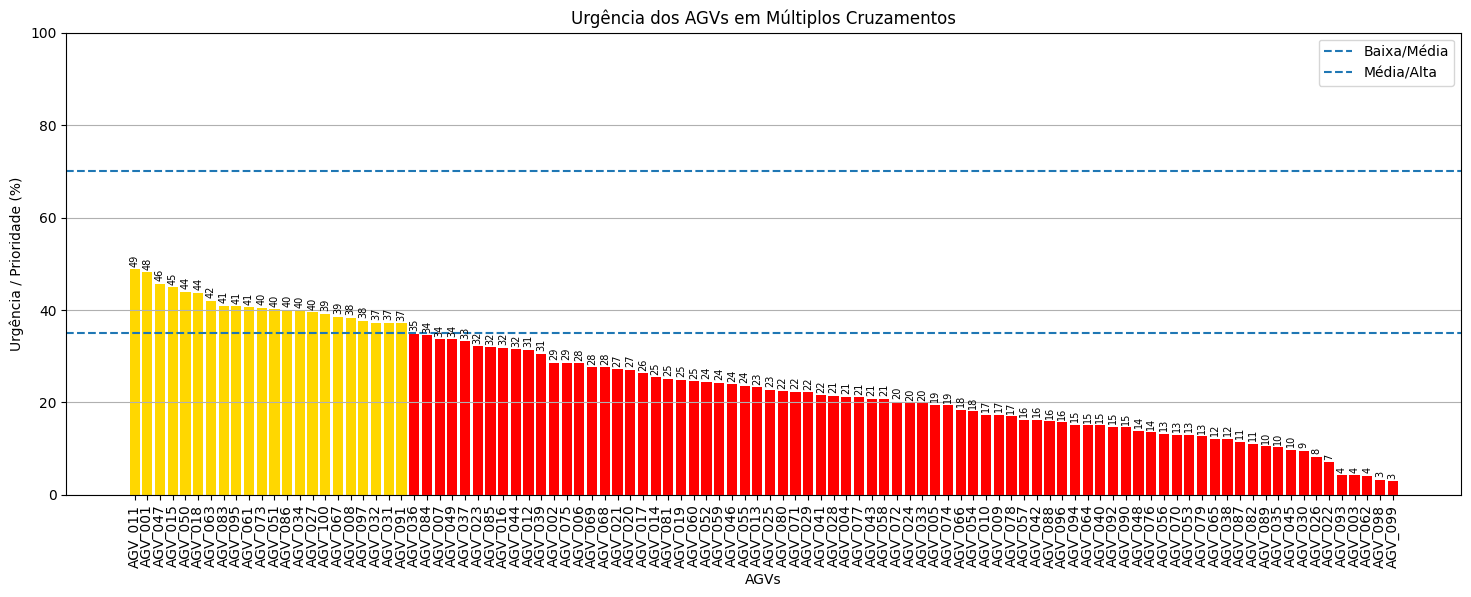

In [20]:
# =========================
# CÉLULA 15 - GRÁFICO DE URGÊNCIA DOS AGVs
# =========================

ids_agvs = []
urgencias_agvs = []
cores = []

for agv in agvs_rna:

    ids_agvs.append(agv["id"])

    urgencias_agvs.append(
        agv["urgencia_rna"]
    )

    # Define cor baseada no semáforo
    if agv["estado_semaforo_rna"] == "VERDE":
        cores.append("green")

    elif agv["estado_semaforo_rna"] == "AMARELO":
        cores.append("gold")

    else:
        cores.append("red")

# =========================
# GRÁFICO
# =========================

plt.figure(figsize=(18, 6))

barras = plt.bar(
    ids_agvs,
    urgencias_agvs,
    color=cores
)

plt.title(
    "Urgência dos AGVs em Múltiplos Cruzamentos"
)

plt.ylabel("Urgência / Prioridade (%)")

plt.xlabel("AGVs")

plt.ylim(0, 100)

plt.xticks(rotation=90)

# Faixas de urgência
plt.axhline(
    35,
    linestyle="--",
    label="Baixa/Média"
)

plt.axhline(
    70,
    linestyle="--",
    label="Média/Alta"
)

plt.grid(axis="y")

plt.legend()

# Exibe valores nas barras
for barra, urgencia in zip(barras, urgencias_agvs):

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        urgencia + 1,
        f"{urgencia:.0f}",
        ha="center",
        fontsize=7,
        rotation=90
    )

plt.show()

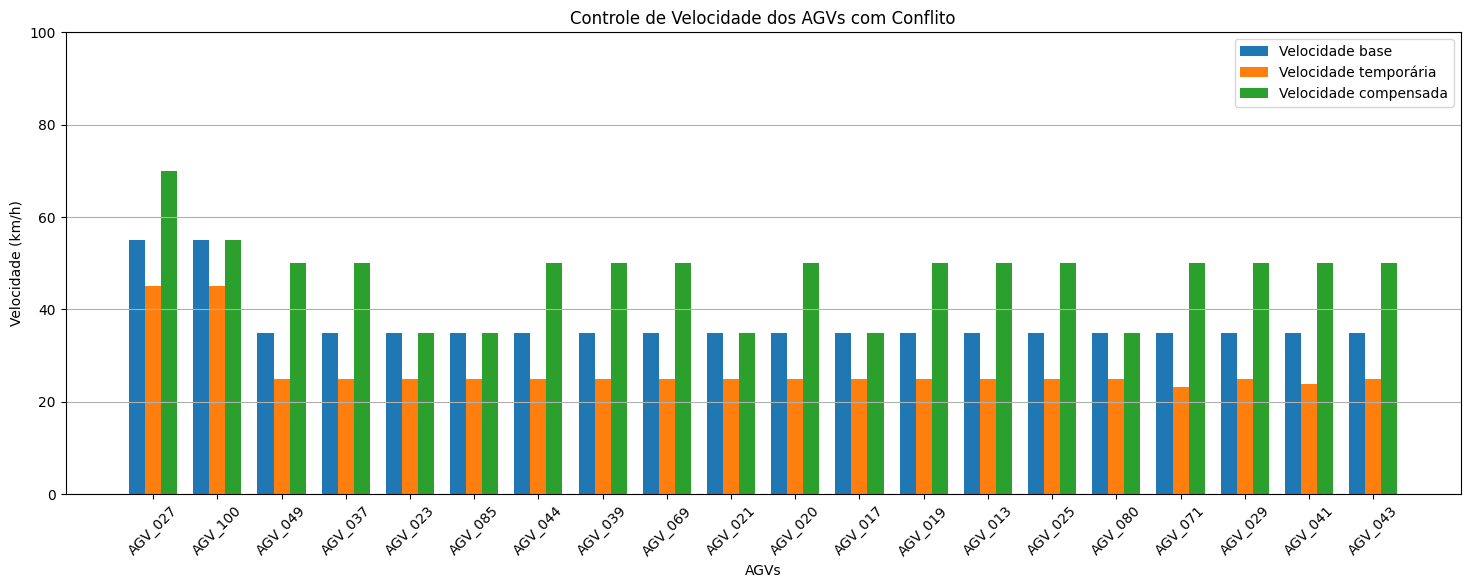

In [21]:
# =========================
# CÉLULA 16 - VELOCIDADES DOS AGVs COM CONFLITO
# =========================

ids_agvs = []

velocidade_base = []
velocidade_temporaria = []
velocidade_compensada = []

# Apenas AGVs que tiveram conflito
agvs_conflito = [

    agv for agv in agvs_rna

    if "velocidade_temporaria" in agv

]

# Limita quantidade para visualização
agvs_conflito = agvs_conflito[:20]

for agv in agvs_conflito:

    ids_agvs.append(
        agv["id"]
    )

    velocidade_base.append(
        agv["velocidade_rna"]
    )

    velocidade_temporaria.append(
        agv["velocidade_temporaria"]
    )

    velocidade_compensada.append(
        agv["velocidade_compensada"]
    )

x = np.arange(len(ids_agvs))

largura = 0.25

plt.figure(figsize=(18, 6))

plt.bar(
    x - largura,
    velocidade_base,
    largura,
    label="Velocidade base"
)

plt.bar(
    x,
    velocidade_temporaria,
    largura,
    label="Velocidade temporária"
)

plt.bar(
    x + largura,
    velocidade_compensada,
    largura,
    label="Velocidade compensada"
)

plt.title(
    "Controle de Velocidade dos AGVs com Conflito"
)

plt.ylabel("Velocidade (km/h)")

plt.xlabel("AGVs")

plt.xticks(
    x,
    ids_agvs,
    rotation=45
)

plt.ylim(0, 100)

plt.grid(axis="y")

plt.legend()

plt.show()

In [22]:
# =========================
# CÉLULA 18 - ESTATÍSTICAS GERAIS DO SISTEMA
# =========================

total_agvs = len(agvs_rna)

agvs_verde = 0
agvs_amarelo = 0
agvs_vermelho = 0

agvs_reduziram = 0
agvs_compensaram = 0

soma_urgencia = 0
soma_velocidade = 0

cruzamentos_utilizados = set()

# =========================
# PROCESSAMENTO
# =========================

for agv in agvs_rna:

    soma_urgencia += agv["urgencia_rna"]

    soma_velocidade += agv["velocidade_rna"]

    cruzamentos_utilizados.add(
        agv["cruzamento_destino"]
    )

    # Semáforos
    if agv["estado_semaforo_rna"] == "VERDE":

        agvs_verde += 1

    elif agv["estado_semaforo_rna"] == "AMARELO":

        agvs_amarelo += 1

    else:

        agvs_vermelho += 1

    # Redução de velocidade
    if "velocidade_temporaria" in agv:

        agvs_reduziram += 1

    # Compensação
    if "velocidade_compensada" in agv:

        if agv["velocidade_compensada"] > agv["velocidade_rna"]:

            agvs_compensaram += 1

# =========================
# MÉDIAS
# =========================

media_urgencia = (
    soma_urgencia / total_agvs
)

media_velocidade = (
    soma_velocidade / total_agvs
)

# =========================
# RESULTADOS
# =========================

print("=" * 80)
print("ESTATÍSTICAS GERAIS DO SISTEMA")
print("=" * 80)

print(f"Quantidade total de AGVs: {total_agvs}")

print()

print(f"Quantidade de cruzamentos utilizados: {len(cruzamentos_utilizados)}")

print(f"Conflitos detectados: {len(conflitos_detectados_rna)}")

print()

print(f"AGVs VERDE: {agvs_verde}")

print(f"AGVs AMARELO: {agvs_amarelo}")

print(f"AGVs VERMELHO: {agvs_vermelho}")

print()

print(f"AGVs que reduziram velocidade: {agvs_reduziram}")

print(f"AGVs que compensaram velocidade: {agvs_compensaram}")

print()

print(f"Média de urgência: {media_urgencia:.2f}%")

print(f"Média de velocidade: {media_velocidade:.2f} km/h")

ESTATÍSTICAS GERAIS DO SISTEMA
Quantidade total de AGVs: 100

Quantidade de cruzamentos utilizados: 5
Conflitos detectados: 76

AGVs VERDE: 0
AGVs AMARELO: 22
AGVs VERMELHO: 78

AGVs que reduziram velocidade: 53
AGVs que compensaram velocidade: 42

Média de urgência: 24.46%
Média de velocidade: 39.40 km/h


In [23]:
# =========================
# CÉLULA 19 - MÉTRICAS DE COLISÃO, COMPENSAÇÃO E TEMPO
# =========================

total_agvs = len(agvs_rna)

qtd_conflitos = len(conflitos_detectados_rna)
qtd_reduziram = 0
qtd_compensaram = 0

soma_compensacao = 0

tempos_base = []
tempos_temporarios = []
tempos_compensados = []

for agv in agvs_rna:

    distancia_destino = agv["distancia_destino"]

    velocidade_base = max(
        agv["velocidade_rna"],
        1
    )

    velocidade_temporaria = max(
        agv.get("velocidade_temporaria", velocidade_base),
        1
    )

    velocidade_compensada = max(
        agv.get("velocidade_compensada", velocidade_base),
        1
    )

    # Tempo estimado simplificado:
    # tempo = distância / velocidade
    tempo_base = distancia_destino / velocidade_base
    tempo_temporario = distancia_destino / velocidade_temporaria
    tempo_compensado = distancia_destino / velocidade_compensada

    tempos_base.append(tempo_base)
    tempos_temporarios.append(tempo_temporario)
    tempos_compensados.append(tempo_compensado)

    if "velocidade_temporaria" in agv:

        qtd_reduziram += 1

        compensacao = (
            velocidade_compensada -
            velocidade_temporaria
        )

        soma_compensacao += compensacao

        if compensacao > 0:
            qtd_compensaram += 1

tempo_medio_base = np.mean(tempos_base)
tempo_medio_temporario = np.mean(tempos_temporarios)
tempo_medio_compensado = np.mean(tempos_compensados)

compensacao_media = (
    soma_compensacao / qtd_reduziram
    if qtd_reduziram > 0
    else 0
)

print("=" * 80)
print("MÉTRICAS DE CONTROLE DOS AGVs EM MÚLTIPLOS CRUZAMENTOS")
print("=" * 80)

print(f"Total de AGVs analisados: {total_agvs}")
print(f"Conflitos detectados em cruzamentos: {qtd_conflitos}")
print(f"AGVs que reduziram velocidade: {qtd_reduziram}")
print(f"AGVs que compensaram velocidade: {qtd_compensaram}")

print("-" * 80)

print(f"Compensação média de velocidade: {compensacao_media:.2f} km/h")

print("-" * 80)

print(f"Tempo médio original de entrega: {tempo_medio_base:.2f}")
print(f"Tempo médio após redução temporária: {tempo_medio_temporario:.2f}")
print(f"Tempo médio após compensação: {tempo_medio_compensado:.2f}")

MÉTRICAS DE CONTROLE DOS AGVs EM MÚLTIPLOS CRUZAMENTOS
Total de AGVs analisados: 100
Conflitos detectados em cruzamentos: 76
AGVs que reduziram velocidade: 53
AGVs que compensaram velocidade: 53
--------------------------------------------------------------------------------
Compensação média de velocidade: 22.56 km/h
--------------------------------------------------------------------------------
Tempo médio original de entrega: 2.25
Tempo médio após redução temporária: 2.82
Tempo médio após compensação: 1.92


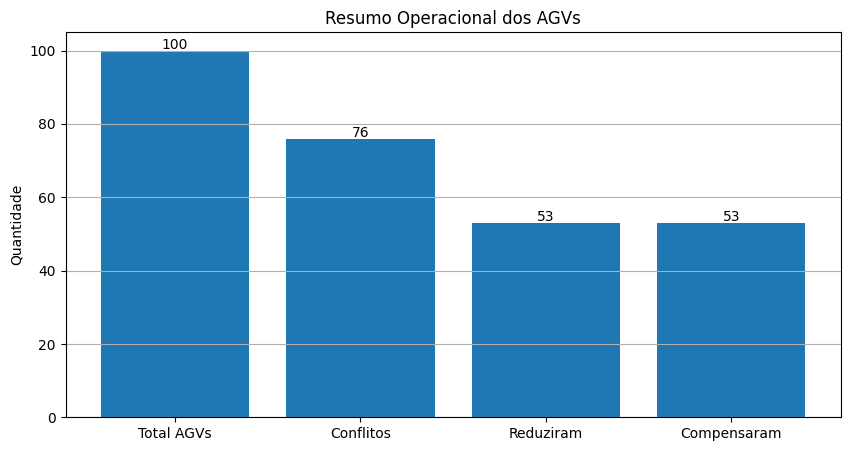

In [24]:
# =========================
# CÉLULA 20 - GRÁFICOS DAS MÉTRICAS FINAIS
# =========================

metricas = [
    "Total AGVs",
    "Conflitos",
    "Reduziram",
    "Compensaram"
]

valores = [
    total_agvs,
    qtd_conflitos,
    qtd_reduziram,
    qtd_compensaram
]

plt.figure(figsize=(10, 5))

barras = plt.bar(metricas, valores)

plt.title("Resumo Operacional dos AGVs")
plt.ylabel("Quantidade")
plt.grid(axis="y")

for barra, valor in zip(barras, valores):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.5,
        str(valor),
        ha="center"
    )

plt.show()

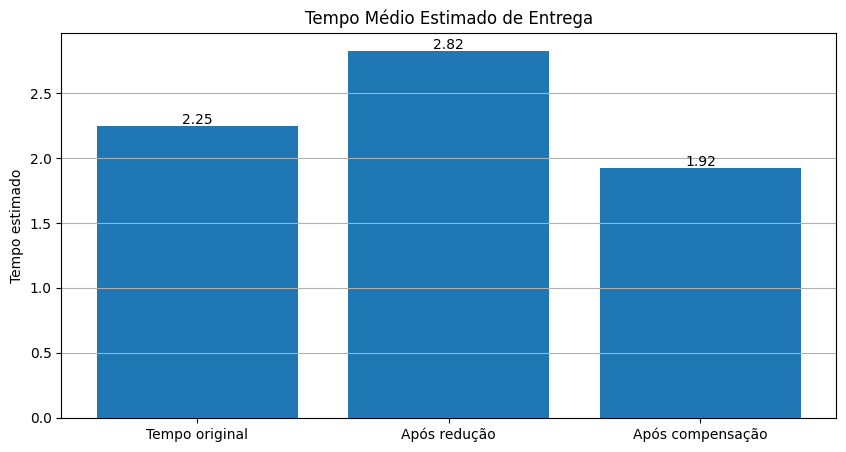

In [25]:
# =========================
# CÉLULA 21 - GRÁFICO DE TEMPOS MÉDIOS
# =========================

nomes_tempos = [
    "Tempo original",
    "Após redução",
    "Após compensação"
]

valores_tempos = [
    tempo_medio_base,
    tempo_medio_temporario,
    tempo_medio_compensado
]

plt.figure(figsize=(10, 5))

barras = plt.bar(nomes_tempos, valores_tempos)

plt.title("Tempo Médio Estimado de Entrega")
plt.ylabel("Tempo estimado")
plt.grid(axis="y")

for barra, valor in zip(barras, valores_tempos):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.2f}",
        ha="center"
    )

plt.show()

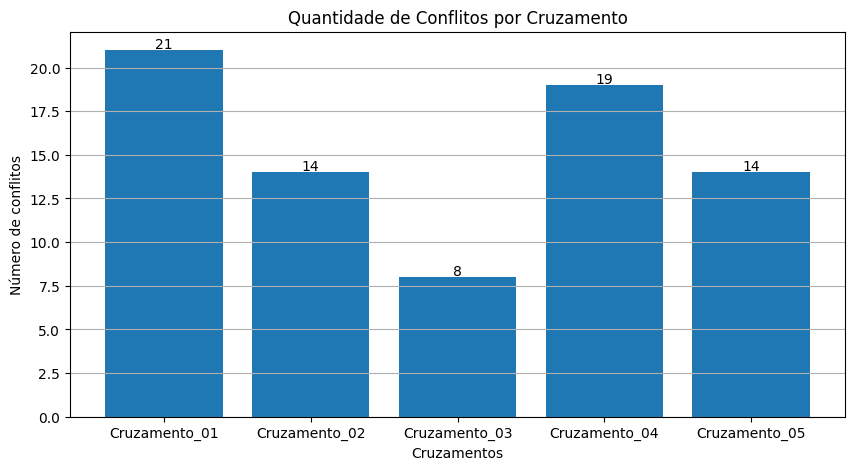

In [26]:
# =========================
# CÉLULA 22 - CONFLITOS POR CRUZAMENTO
# =========================

conflitos_por_cruzamento = {}

for conflito in conflitos_detectados_rna:

    cruzamento = conflito["cruzamento"]

    if cruzamento not in conflitos_por_cruzamento:
        conflitos_por_cruzamento[cruzamento] = 0

    conflitos_por_cruzamento[cruzamento] += 1

nomes_cruzamentos = list(conflitos_por_cruzamento.keys())
quantidade_conflitos = list(conflitos_por_cruzamento.values())

plt.figure(figsize=(10, 5))

barras = plt.bar(
    nomes_cruzamentos,
    quantidade_conflitos
)

plt.title("Quantidade de Conflitos por Cruzamento")
plt.ylabel("Número de conflitos")
plt.xlabel("Cruzamentos")

plt.grid(axis="y")

for barra, valor in zip(barras, quantidade_conflitos):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.1,
        str(valor),
        ha="center"
    )

plt.show()

In [27]:
# =========================
# CÉLULA 23 - ANÁLISE GEMINI DOS CONFLITOS
# =========================

def gerar_resumo_conflitos_para_gemini():
    """
    Gera um resumo compacto dos conflitos detectados
    para enviar ao Gemini.
    """

    if len(conflitos_detectados_rna) == 0:
        return "Nenhum conflito foi detectado nos cruzamentos."

    resumo = ""

    for i, conflito in enumerate(conflitos_detectados_rna[:10], start=1):

        resumo += f"""
Conflito {i}:
- Cruzamento: {conflito['cruzamento']}
- AGV prioritário: {conflito['agv_prioritario']}
- Urgência do prioritário: {conflito['urgencia_prioritario']:.2f}%
- AGV secundário: {conflito['agv_secundario']}
- Urgência do secundário: {conflito['urgencia_secundario']:.2f}%
- Diferença de tempo de chegada: {conflito['diferenca_tempo']:.2f}
- Velocidade original do secundário: {conflito['velocidade_original_secundario']:.1f}
- Velocidade temporária do secundário: {conflito['velocidade_temporaria_secundario']:.1f}
- Tempo original do secundário: {conflito['tempo_original_secundario']:.2f}
- Tempo ajustado do secundário: {conflito['tempo_ajustado_secundario']:.2f}
"""

    return resumo


def analisar_conflitos_com_gemini():
    """
    Envia os resultados do sistema para o Gemini
    e retorna uma análise objetiva.
    """

    resumo_conflitos = gerar_resumo_conflitos_para_gemini()

    prompt_gemini = f"""
Você é um especialista em logística industrial 4.0, AGVs, controle de tráfego autônomo e manutenção preditiva.

Analise o sistema abaixo.

Resumo geral:
- Total de AGVs analisados: {total_agvs}
- Total de conflitos detectados em cruzamentos: {qtd_conflitos}
- AGVs que reduziram velocidade: {qtd_reduziram}
- AGVs que compensaram velocidade: {qtd_compensaram}
- Tempo médio original de entrega: {tempo_medio_base:.2f}
- Tempo médio após redução temporária: {tempo_medio_temporario:.2f}
- Tempo médio após compensação: {tempo_medio_compensado:.2f}

Conflitos principais:
{resumo_conflitos}

Faça uma análise curta e objetiva contendo:
1. O que o sistema identificou
2. Por que alguns AGVs reduziram velocidade
3. Como a prioridade foi definida
4. Como a compensação ajuda a reduzir atrasos
5. Uma conclusão final sobre eficiência e segurança

Responda em português brasileiro.
"""

    resposta = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=prompt_gemini
    )

    return resposta.text


try:
    print("=" * 80)
    print("ANÁLISE DO GEMINI SOBRE O SISTEMA")
    print("=" * 80)

    analise = analisar_conflitos_com_gemini()

    print(analise)

except Exception as erro:
    print("Erro ao utilizar o Gemini.")
    print(erro)

ANÁLISE DO GEMINI SOBRE O SISTEMA
Como especialista em logística 4.0, apresento a análise técnica dos dados fornecidos:

### 1. O que o sistema identificou
O sistema detectou uma **alta densidade de tráfego com gargalo crítico no Cruzamento_01**. Dos 100 AGVs, 76% apresentaram conflitos de trajetória. A telemetria identificou riscos de colisão iminentes, com diferenças de tempo de chegada extremamente baixas (chegando a apenas 0.01s em alguns casos), o que exigiu intervenção imediata da camada de controle autônomo.

### 2. Por que alguns AGVs reduziram velocidade
A redução (de 35.0 para 25.0 ou 20.0 unidades de velocidade) foi uma **manobra de evasão proativa**. Os AGVs classificados como "secundários" desaceleraram para criar uma janela de segurança (gap temporal), permitindo que o AGV prioritário atravessasse o cruzamento sem necessidade de parada total (*stop-and-go*), o que preserva a vida útil dos componentes e economiza energia.

### 3. Como a prioridade foi definida
A prioridade

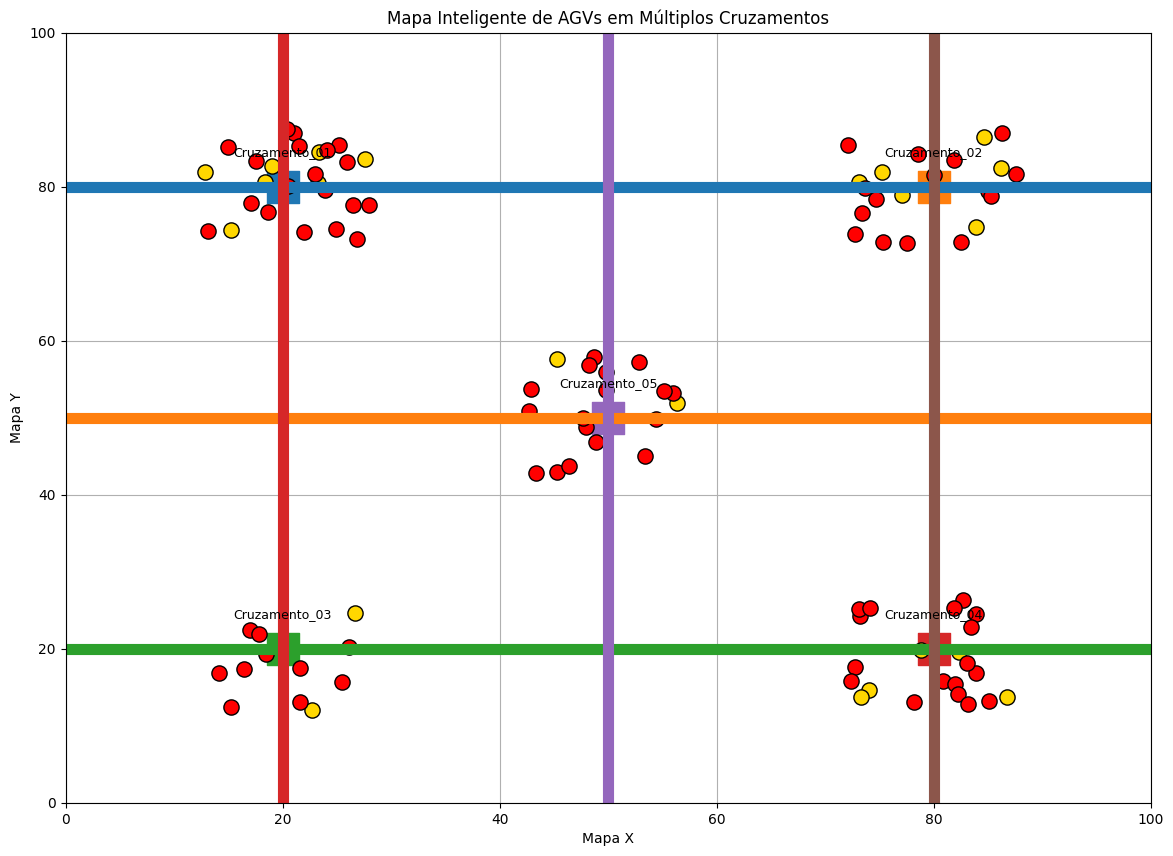

In [28]:
# =========================
# CÉLULA 24 - MAPA VISUAL DOS AGVs
# =========================

plt.figure(figsize=(14, 10))

# =========================
# POSIÇÕES DOS CRUZAMENTOS
# =========================

posicoes_cruzamentos = {
    "Cruzamento_01": (20, 80),
    "Cruzamento_02": (80, 80),
    "Cruzamento_03": (20, 20),
    "Cruzamento_04": (80, 20),
    "Cruzamento_05": (50, 50)
}

# =========================
# DESENHA CORREDORES
# =========================

# Horizontais
plt.plot([0, 100], [80, 80], linewidth=8)
plt.plot([0, 100], [50, 50], linewidth=8)
plt.plot([0, 100], [20, 20], linewidth=8)

# Verticais
plt.plot([20, 20], [0, 100], linewidth=8)
plt.plot([50, 50], [0, 100], linewidth=8)
plt.plot([80, 80], [0, 100], linewidth=8)

# =========================
# DESENHA CRUZAMENTOS
# =========================

for nome, (x, y) in posicoes_cruzamentos.items():

    plt.scatter(
        x,
        y,
        s=500,
        marker='s'
    )

    plt.text(
        x,
        y + 4,
        nome,
        ha='center',
        fontsize=9
    )

# =========================
# DESENHA AGVs
# =========================

for agv in agvs_rna:

    cruzamento = agv["cruzamento_destino"]

    x_base, y_base = posicoes_cruzamentos[cruzamento]

    # Pequena variação aleatória para espalhar AGVs
    x = x_base + np.random.uniform(-8, 8)
    y = y_base + np.random.uniform(-8, 8)

    # Cor pelo semáforo
    estado = agv["estado_semaforo_rna"]

    if estado == "VERDE":
        cor = "green"

    elif estado == "AMARELO":
        cor = "gold"

    else:
        cor = "red"

    plt.scatter(
        x,
        y,
        s=120,
        c=cor,
        edgecolors='black'
    )

# =========================
# VISUAL FINAL
# =========================

plt.title(
    "Mapa Inteligente de AGVs em Múltiplos Cruzamentos"
)

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.grid(True)

plt.xlabel("Mapa X")
plt.ylabel("Mapa Y")

plt.show()

In [29]:
# =========================
# CÉLULA 25 - SIMULAÇÃO TEMPORAL DOS AGVs
# =========================

# Quantidade de instantes simulados
passos_tempo = 10

# Cópia dos dados principais para simulação
agvs_simulacao = []

for agv in agvs_rna:

    agvs_simulacao.append({
        "id": agv["id"],
        "cruzamento": agv["cruzamento_destino"],
        "distancia_cruzamento": agv["distancia_cruzamento"],
        "velocidade": agv.get("velocidade_temporaria", agv["velocidade_rna"]),
        "urgencia": agv["urgencia_rna"],
        "estado": agv["estado_semaforo_rna"]
    })

print("=" * 80)
print("SIMULAÇÃO TEMPORAL DOS AGVs")
print("=" * 80)

for t in range(passos_tempo):

    print("\n" + "=" * 80)
    print(f"INSTANTE t = {t}")
    print("=" * 80)

    for agv in agvs_simulacao[:20]:

        # Atualiza distância até o cruzamento
        agv["distancia_cruzamento"] = max(
            0,
            agv["distancia_cruzamento"] - agv["velocidade"] * 0.1
        )

        print(
            f"{agv['id']} | "
            f"Cruzamento: {agv['cruzamento']} | "
            f"Distância restante: {agv['distancia_cruzamento']:.2f} | "
            f"Velocidade: {agv['velocidade']:.1f} | "
            f"Urgência: {agv['urgencia']:.1f}% | "
            f"Estado: {agv['estado']}"
        )

print("\nSimulação temporal concluída.")

SIMULAÇÃO TEMPORAL DOS AGVs

INSTANTE t = 0
AGV_011 | Cruzamento: Cruzamento_02 | Distância restante: 83.50 | Velocidade: 55.0 | Urgência: 48.8% | Estado: AMARELO
AGV_001 | Cruzamento: Cruzamento_01 | Distância restante: 31.50 | Velocidade: 55.0 | Urgência: 48.2% | Estado: AMARELO
AGV_047 | Cruzamento: Cruzamento_01 | Distância restante: 96.50 | Velocidade: 55.0 | Urgência: 45.6% | Estado: AMARELO
AGV_015 | Cruzamento: Cruzamento_05 | Distância restante: 21.50 | Velocidade: 55.0 | Urgência: 44.9% | Estado: AMARELO
AGV_050 | Cruzamento: Cruzamento_01 | Distância restante: 98.50 | Velocidade: 55.0 | Urgência: 43.9% | Estado: AMARELO
AGV_018 | Cruzamento: Cruzamento_01 | Distância restante: 66.50 | Velocidade: 55.0 | Urgência: 43.7% | Estado: AMARELO
AGV_063 | Cruzamento: Cruzamento_04 | Distância restante: 84.50 | Velocidade: 55.0 | Urgência: 42.0% | Estado: AMARELO
AGV_083 | Cruzamento: Cruzamento_03 | Distância restante: 68.50 | Velocidade: 55.0 | Urgência: 40.9% | Estado: AMARELO
AGV_

In [30]:
# =========================
# CÉLULA 26 - DASHBOARD INTERATIVO DOS AGVs
# =========================

# Slider para escolher quantidade de AGVs exibidos
slider_qtd_agvs = widgets.IntSlider(
    value=20,
    min=5,
    max=len(agvs_rna),
    step=5,
    description="Qtd AGVs:"
)

# Dropdown para escolher cruzamento
dropdown_cruzamento = widgets.Dropdown(
    options=["Todos"] + cruzamentos,
    value="Todos",
    description="Cruzamento:"
)

# Slider para passos de tempo
slider_passos = widgets.IntSlider(
    value=10,
    min=1,
    max=30,
    step=1,
    description="Passos:"
)

saida_dashboard = widgets.Output()


def atualizar_dashboard_agv(change=None):

    with saida_dashboard:

        clear_output(wait=True)

        qtd = slider_qtd_agvs.value
        cruzamento_selecionado = dropdown_cruzamento.value
        passos = slider_passos.value

        if cruzamento_selecionado == "Todos":

            dados = agvs_rna[:qtd]

        else:

            dados = [
                agv for agv in agvs_rna
                if agv["cruzamento_destino"] == cruzamento_selecionado
            ][:qtd]

        print("=" * 80)
        print("DASHBOARD INTERATIVO DE AGVs")
        print("=" * 80)

        print(f"AGVs exibidos: {len(dados)}")
        print(f"Cruzamento selecionado: {cruzamento_selecionado}")
        print(f"Passos simulados: {passos}")

        print("-" * 80)

        for agv in dados:

            print(
                f"{agv['id']} | "
                f"Cruzamento: {agv['cruzamento_destino']} | "
                f"Urgência: {agv['urgencia_rna']:.2f}% | "
                f"Semáforo: {agv['estado_semaforo_rna']} | "
                f"Velocidade: {agv.get('velocidade_temporaria', agv['velocidade_rna']):.1f}"
            )

        # Gráfico de urgência dos AGVs selecionados
        ids = [agv["id"] for agv in dados]
        urgencias = [agv["urgencia_rna"] for agv in dados]

        plt.figure(figsize=(12, 5))

        plt.bar(ids, urgencias)

        plt.title("Urgência dos AGVs Selecionados")
        plt.ylabel("Urgência (%)")
        plt.ylim(0, 100)
        plt.xticks(rotation=45)
        plt.grid(axis="y")

        plt.show()


slider_qtd_agvs.observe(
    atualizar_dashboard_agv,
    names="value"
)

dropdown_cruzamento.observe(
    atualizar_dashboard_agv,
    names="value"
)

slider_passos.observe(
    atualizar_dashboard_agv,
    names="value"
)

display(
    slider_qtd_agvs,
    dropdown_cruzamento,
    slider_passos,
    saida_dashboard
)

atualizar_dashboard_agv()

IntSlider(value=20, description='Qtd AGVs:', min=5, step=5)

Dropdown(description='Cruzamento:', options=('Todos', 'Cruzamento_01', 'Cruzamento_02', 'Cruzamento_03', 'Cruz…

IntSlider(value=10, description='Passos:', max=30, min=1)

Output()

COMPARAÇÃO COM E SEM CONTROLE INTELIGENTE
Conflitos estimados sem controle: 76
Conflitos mitigados pelo sistema: 53
Conflitos restantes após controle: 23
Eficiência do controle: 69.74%


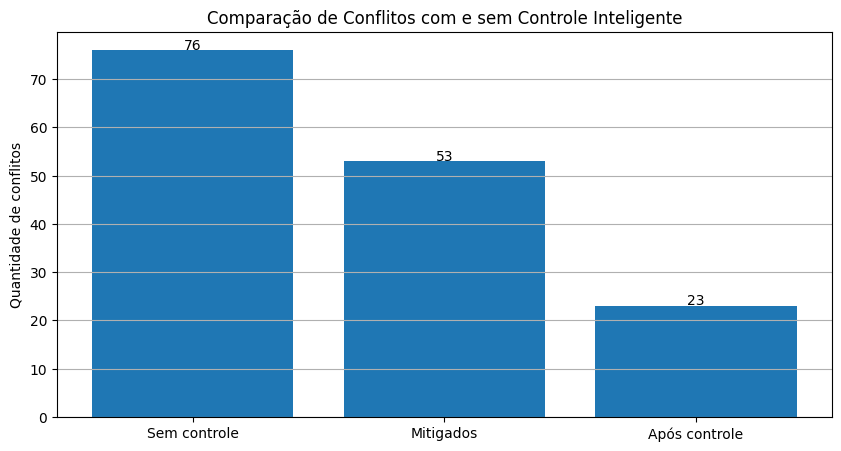

In [31]:
# =========================
# CÉLULA 27 - COMPARAÇÃO COM E SEM CONTROLE INTELIGENTE
# =========================

# Cenário sem controle:
# considera que todo conflito detectado poderia gerar risco operacional
conflitos_sem_controle = len(conflitos_detectados_rna)

# Cenário com controle:
# considera que conflitos com redução de velocidade foram mitigados
conflitos_mitigados = 0

for agv in agvs_rna:
    if "velocidade_temporaria" in agv:
        conflitos_mitigados += 1

# Como um conflito pode envolver um AGV secundário,
# limitamos a quantidade mitigada ao total de conflitos detectados
conflitos_mitigados = min(
    conflitos_mitigados,
    conflitos_sem_controle
)

conflitos_com_controle = max(
    0,
    conflitos_sem_controle - conflitos_mitigados
)

eficiencia_controle = (
    (conflitos_mitigados / conflitos_sem_controle) * 100
    if conflitos_sem_controle > 0
    else 100
)

print("=" * 80)
print("COMPARAÇÃO COM E SEM CONTROLE INTELIGENTE")
print("=" * 80)

print(f"Conflitos estimados sem controle: {conflitos_sem_controle}")
print(f"Conflitos mitigados pelo sistema: {conflitos_mitigados}")
print(f"Conflitos restantes após controle: {conflitos_com_controle}")
print(f"Eficiência do controle: {eficiencia_controle:.2f}%")

# =========================
# GRÁFICO
# =========================

categorias = [
    "Sem controle",
    "Mitigados",
    "Após controle"
]

valores = [
    conflitos_sem_controle,
    conflitos_mitigados,
    conflitos_com_controle
]

plt.figure(figsize=(10, 5))

barras = plt.bar(
    categorias,
    valores
)

plt.title("Comparação de Conflitos com e sem Controle Inteligente")
plt.ylabel("Quantidade de conflitos")
plt.grid(axis="y")

for barra, valor in zip(barras, valores):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.2,
        str(valor),
        ha="center"
    )

plt.show()

In [32]:
# =========================
# CÉLULA 28 - SALVAR HISTÓRICO EM CSV
# =========================

import pandas as pd

historico_agvs = []

for agv in agvs_rna:

    historico_agvs.append({
        "id": agv["id"],
        "corredor": agv["corredor"],
        "cruzamento_destino": agv["cruzamento_destino"],
        "tempo_restante": agv["tempo_restante"],
        "distancia_destino": agv["distancia_destino"],
        "prioridade_entrega": agv["prioridade_entrega"],
        "urgencia_rna": agv["urgencia_rna"],
        "semaforo": agv["estado_semaforo_rna"],
        "velocidade_base": agv["velocidade_rna"],
        "velocidade_temporaria": agv.get("velocidade_temporaria", agv["velocidade_rna"]),
        "velocidade_compensada": agv.get("velocidade_compensada", agv["velocidade_rna"]),
        "cedeu_passagem": agv.get("cedeu_passagem", False),
        "cruzamento_conflito": agv.get("cruzamento_conflito", "Sem conflito")
    })

df_historico = pd.DataFrame(historico_agvs)

df_historico.to_csv(
    "historico_agvs.csv",
    index=False
)

print("=" * 80)
print("HISTÓRICO SALVO COM SUCESSO")
print("=" * 80)

print("Arquivo gerado: historico_agvs.csv")

df_historico.head(100)

HISTÓRICO SALVO COM SUCESSO
Arquivo gerado: historico_agvs.csv


,id,corredor,cruzamento_destino,tempo_restante,distancia_destino,prioridade_entrega,urgencia_rna,semaforo,velocidade_base,velocidade_temporaria,velocidade_compensada,cedeu_passagem,cruzamento_conflito
0,AGV_011,E,Cruzamento_02,4,103,92,48.847973,AMARELO,55,55.0,55,False,Sem conflito
1,AGV_001,E,Cruzamento_01,3,25,87,48.196405,AMARELO,55,55.0,55,False,Sem conflito
2,AGV_047,A,Cruzamento_01,3,76,78,45.624551,AMARELO,55,55.0,55,False,Sem conflito
3,AGV_015,A,Cruzamento_05,6,58,93,44.929833,AMARELO,55,55.0,55,False,Sem conflito
4,AGV_050,A,Cruzamento_01,3,119,71,43.886081,AMARELO,55,55.0,55,False,Sem conflito
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,AGV_093,D,Cruzamento_05,24,75,3,4.238874,VERMELHO,35,25.0,50,True,Cruzamento_05
96,AGV_003,D,Cruzamento_01,25,128,1,4.164806,VERMELHO,35,20.0,50,True,Cruzamento_01
97,AGV_062,B,Cruzamento_04,13,56,0,4.116720,VERMELHO,35,20.0,50,True,Cruzamento_04
98,AGV_098,E,Cruzamento_03,18,44,0,3.225209,VERMELHO,35,35.0,35,False,Sem conflito


In [33]:
# =========================
# CÉLULA 29 - CONCLUSÃO FINAL COM GEMINI
# =========================

def gerar_conclusao_final():

    prompt = f"""
Você é um especialista em logística inteligente, AGVs industriais,
IA aplicada à automação e Indústria 4.0.

Com base nos resultados abaixo, gere uma conclusão técnica objetiva
para um projeto acadêmico de Engenharia de Controle e Automação.

RESULTADOS:

- Total de AGVs analisados: {total_agvs}
- Quantidade de cruzamentos: {len(cruzamentos)}
- Conflitos detectados: {qtd_conflitos}
- AGVs que reduziram velocidade: {qtd_reduziram}
- AGVs que compensaram velocidade: {qtd_compensaram}

- Média de urgência: {media_urgencia:.2f}%
- Média de velocidade: {media_velocidade:.2f} km/h

- Tempo médio original: {tempo_medio_base:.2f}
- Tempo médio após redução: {tempo_medio_temporario:.2f}
- Tempo médio após compensação: {tempo_medio_compensado:.2f}

- Eficiência do sistema de controle: {eficiencia_controle:.2f}%

Explique:
1. O funcionamento do sistema
2. O papel da RNA
3. O papel do controle inteligente
4. Como o sistema evita colisões
5. Como a compensação reduz atrasos
6. Benefícios para logística industrial
7. Uma conclusão final sobre eficiência e segurança

Responda em português brasileiro.
"""

    resposta = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=prompt
    )

    return resposta.text


try:

    print("=" * 100)
    print("CONCLUSÃO FINAL DO PROJETO")
    print("=" * 100)

    conclusao = gerar_conclusao_final()

    print(conclusao)

except Exception as erro:

    print("Erro ao gerar conclusão com Gemini.")
    print(erro)

CONCLUSÃO FINAL DO PROJETO
Esta é uma conclusão técnica estruturada para um projeto de Engenharia de Controle e Automação, redigida sob a ótica de um especialista em Indústria 4.0.

---

### Conclusão Técnica: Otimização de Tráfego de AGVs via Redes Neurais e Controle Inteligente

Os resultados obtidos na análise de 100 AGVs (Veículos Guiados Automatizados) em um cenário de alta densidade de tráfego (76 conflitos detectados em apenas 5 cruzamentos) demonstram a eficácia da aplicação de inteligência computacional na logística industrial. O sistema não apenas garantiu a integridade física dos ativos, mas otimizou o *throughput* operacional.

#### 1. Funcionamento do Sistema
O sistema opera como um ecossistema de logística descentralizada. Cada AGV atua como um agente em uma rede monitorada, onde as trajetórias são constantemente cruzadas em busca de pontos de intersecção temporal e espacial. Ao detectar um conflito iminente em um dos 5 cruzamentos, o sistema central de gerenciamento de f

In [34]:
# =========================
# TESTE SIMPLES DO GEMINI
# =========================

try:
    resposta = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents="Responda apenas com: Oi"
    )

    print("Gemini funcionando corretamente.")
    print("Resposta:")
    print(resposta.text)

except Exception as erro:
    print("Erro ao testar o Gemini.")
    print(erro)

Gemini funcionando corretamente.
Resposta:
Oi
